In [2]:
import pandas as pd
import numpy as np

In [3]:
class_df = pd.read_csv("clean_crop_contribution_data/aggregated_data/kmeans_classes/rice_classified.csv")

In [4]:
class_df

,State,District,Median,Max,Yield_Class
0,A & N Islands,Nicobars,1.730,5.77,Medium
1,A & N Islands,North And Middle Andaman,2.185,3.16,High
2,A & N Islands,South Andamans,2.435,3.04,High
3,Andhra Pradesh,Alluri Sitharama Raju,2.990,2.99,High
4,Andhra Pradesh,Anakapalli,3.140,3.14,High
...,...,...,...,...,...
719,West Bengal,Murshidabad,2.910,3.29,High
720,West Bengal,Nadia,2.920,3.34,High
721,West Bengal,Paschim Bardhaman,3.090,3.39,High
722,West Bengal,Purba Bardhaman,3.070,3.59,High


In [5]:
features_df = pd.read_csv('engineered_climate_features_slight_correlation.csv')

In [6]:
features_df

,location,tp_kharif_mean,tp_kharif_std,e_kharif_mean,e_kharif_std,swvl1_kharif_mean,soil_air_diff_kharif_mean,soil_air_diff_kharif_std,runoff_ratio_kharif_mean,e_rabi_mean,...,GDD_rabi,heat_months_30C,heat_months_35C,humidity_variability,swvl1_amplitude,swvl1_stability,soil_moisture_seasonality,cvh,water_retention_index,humidity_stress_index
0,A & N Islands_Nicobars,0.212075,0.009158,-0.144988,0.012498,5.571480e-07,1.401477,0.055918,0.000000,-0.124398,...,67.030034,0,0,0.403557,0.000005,9.164305,-3.721546e-07,0.000000,0.357962,8.448173
1,A & N Islands_North And Middle Andaman,0.337536,0.009329,-0.137305,0.010667,1.246314e-01,1.206633,0.090948,0.127147,-0.133948,...,66.739761,0,0,1.009721,0.082650,0.663154,2.567770e-02,0.097324,0.171858,3.615982
2,A & N Islands_South Andamans,0.311476,0.022785,-0.144685,0.010310,1.675441e-02,1.314073,0.136034,0.024587,-0.137583,...,67.797892,0,0,0.846505,0.010900,0.650601,3.163555e-03,0.009017,0.277637,4.320013
3,Andhra Pradesh_Alluri Sitharama Raju,0.312446,0.044864,-0.094966,0.003045,3.896810e-01,0.550737,0.154662,0.452236,-0.079284,...,50.285603,0,0,1.968619,0.238318,0.611573,1.239291e-01,0.737434,-0.059075,2.707588
4,Andhra Pradesh_Anakapalli,0.228586,0.028609,-0.107531,0.002641,2.852737e-01,0.548313,0.174455,0.237716,-0.086047,...,56.039035,1,0,0.958582,0.191011,0.669571,9.344429e-02,0.403020,-0.069854,4.945039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
768,West Bengal_Murshidabad,0.275707,0.021696,-0.112844,0.002819,3.844570e-01,0.641541,0.069157,0.356913,-0.073634,...,46.448733,2,0,1.888184,0.212852,0.553644,1.418102e-01,0.333241,-0.090637,2.708996
769,West Bengal_Nadia,0.278344,0.025523,-0.114582,0.002691,3.855084e-01,0.673007,0.080176,0.361696,-0.077410,...,47.466119,2,0,1.631112,0.208986,0.542105,1.389152e-01,0.082477,-0.103035,2.954232
770,West Bengal_Paschim Bardhaman,0.253455,0.021283,-0.109788,0.001778,3.772881e-01,0.754295,0.127140,0.257821,-0.070918,...,44.891160,3,0,2.463836,0.218843,0.580043,1.424418e-01,0.344329,-0.068096,2.365677
771,West Bengal_Purba Bardhaman,0.270052,0.023807,-0.110861,0.002242,3.840139e-01,0.635673,0.069839,0.336611,-0.072089,...,47.207326,3,0,1.842454,0.212822,0.554204,1.423393e-01,0.354676,-0.079435,2.812093


In [7]:
class_df["location"] = class_df["State"] + "_" + class_df["District"]
merged_df = class_df.merge(features_df, on="location", how="inner")
print(merged_df.shape)
merged_df

(720, 42)


,State,District,Median,Max,Yield_Class,location,tp_kharif_mean,tp_kharif_std,e_kharif_mean,e_kharif_std,...,GDD_rabi,heat_months_30C,heat_months_35C,humidity_variability,swvl1_amplitude,swvl1_stability,soil_moisture_seasonality,cvh,water_retention_index,humidity_stress_index
0,A & N Islands,Nicobars,1.730,5.77,Medium,A & N Islands_Nicobars,0.212075,0.009158,-0.144988,0.012498,...,67.030034,0,0,0.403557,0.000005,9.164305,-3.721546e-07,0.000000,0.357962,8.448173
1,A & N Islands,North And Middle Andaman,2.185,3.16,High,A & N Islands_North And Middle Andaman,0.337536,0.009329,-0.137305,0.010667,...,66.739761,0,0,1.009721,0.082650,0.663154,2.567770e-02,0.097324,0.171858,3.615982
2,A & N Islands,South Andamans,2.435,3.04,High,A & N Islands_South Andamans,0.311476,0.022785,-0.144685,0.010310,...,67.797892,0,0,0.846505,0.010900,0.650601,3.163555e-03,0.009017,0.277637,4.320013
3,Andhra Pradesh,Alluri Sitharama Raju,2.990,2.99,High,Andhra Pradesh_Alluri Sitharama Raju,0.312446,0.044864,-0.094966,0.003045,...,50.285603,0,0,1.968619,0.238318,0.611573,1.239291e-01,0.737434,-0.059075,2.707588
4,Andhra Pradesh,Anakapalli,3.140,3.14,High,Andhra Pradesh_Anakapalli,0.228586,0.028609,-0.107531,0.002641,...,56.039035,1,0,0.958582,0.191011,0.669571,9.344429e-02,0.403020,-0.069854,4.945039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,West Bengal,Murshidabad,2.910,3.29,High,West Bengal_Murshidabad,0.275707,0.021696,-0.112844,0.002819,...,46.448733,2,0,1.888184,0.212852,0.553644,1.418102e-01,0.333241,-0.090637,2.708996
716,West Bengal,Nadia,2.920,3.34,High,West Bengal_Nadia,0.278344,0.025523,-0.114582,0.002691,...,47.466119,2,0,1.631112,0.208986,0.542105,1.389152e-01,0.082477,-0.103035,2.954232
717,West Bengal,Paschim Bardhaman,3.090,3.39,High,West Bengal_Paschim Bardhaman,0.253455,0.021283,-0.109788,0.001778,...,44.891160,3,0,2.463836,0.218843,0.580043,1.424418e-01,0.344329,-0.068096,2.365677
718,West Bengal,Purba Bardhaman,3.070,3.59,High,West Bengal_Purba Bardhaman,0.270052,0.023807,-0.110861,0.002242,...,47.207326,3,0,1.842454,0.212822,0.554204,1.423393e-01,0.354676,-0.079435,2.812093


In [8]:
set(class_df["location"]) - set(features_df["location"])

{'Nagaland_Dimapur', 'Nagaland_Niuland', 'Puducherry_Mahe', 'Puducherry_Yanam'}

In [9]:
print(merged_df["Yield_Class"].value_counts())
print(merged_df["Yield_Class"].value_counts(normalize=True))

Yield_Class
High      349
Medium    305
Low        66
Name: count, dtype: int64
Yield_Class
High      0.484722
Medium    0.423611
Low       0.091667
Name: proportion, dtype: float64


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
merged_df["Yield_Class_Encoded"] = le.fit_transform(merged_df["Yield_Class"])

print("\nEncoding mapping:")
print(dict(zip(le.classes_, le.transform(le.classes_))))


Encoding mapping:
{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [11]:
drop_cols = ["State", "District", "location", "Median", "Max", "Yield_Class"]

X = merged_df.drop(columns=drop_cols + ["Yield_Class_Encoded"])
y = merged_df["Yield_Class_Encoded"]

print("\nFeature shape:", X.shape)


Feature shape: (720, 36)


In [12]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
class_weight_dict = dict(zip(classes, weights))
sample_weights = y.map(class_weight_dict)

In [13]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_metrics = []
shap_importance_list = []

In [14]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import shap

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):

    print(f"\n====================")
    print(f"Fold {fold+1}")
    print(f"====================")

    X_train = X.iloc[train_idx]
    X_val   = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val   = y.iloc[val_idx]

    # KNN requires feature scaling
    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)

    model = KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",  # weight by inverse distance
        metric="minkowski"
    )

    # Note: KNN does not support sample_weight in fit()
    model.fit(X_train_scaled, y_train)

    # ---------------- Metrics ----------------
    preds = model.predict(X_val_scaled)
    acc   = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds, average="weighted")
    fold_metrics.append((acc, f1))

    print("Accuracy:", acc)
    print("F1:", f1)

    # ---------------- SHAP ----------------
    # KNN has no TreeExplainer; use KernelExplainer with sampled background
    background  = shap.sample(X_train_scaled, 50)
    explainer   = shap.KernelExplainer(model.predict_proba, background)
    shap_values = explainer.shap_values(X_val_scaled, nsamples=100)

    if isinstance(shap_values, list):
        shap_vals = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    elif shap_values.ndim == 3:
        shap_vals = np.abs(shap_values).mean(axis=2)
    else:
        shap_vals = np.abs(shap_values)

    shap_mean = shap_vals.mean(axis=0)
    shap_importance_list.append(shap_mean)


Fold 1
Accuracy: 0.7638888888888888
F1: 0.7616238416221948


  0%|          | 0/144 [00:00<?, ?it/s]


Fold 2
Accuracy: 0.7986111111111112
F1: 0.7992643957826441


  0%|          | 0/144 [00:00<?, ?it/s]


Fold 3
Accuracy: 0.7916666666666666
F1: 0.7906603810188958


  0%|          | 0/144 [00:00<?, ?it/s]


Fold 4
Accuracy: 0.75
F1: 0.7510763564685132


  0%|          | 0/144 [00:00<?, ?it/s]


Fold 5
Accuracy: 0.7569444444444444
F1: 0.7478789656993658


  0%|          | 0/144 [00:00<?, ?it/s]

In [15]:
fold_metrics = np.array(fold_metrics)

print("\n====================")
print("FINAL CV METRICS")
print("====================")
print("Accuracy mean:", fold_metrics[:,0].mean())
print("Accuracy std:",  fold_metrics[:,0].std())
print("F1 mean:",       fold_metrics[:,1].mean())
print("F1 std:",        fold_metrics[:,1].std())


FINAL CV METRICS
Accuracy mean: 0.7722222222222221
Accuracy std: 0.019344983718311292
F1 mean: 0.7701007881183227
F1 std: 0.020980037585056427


In [16]:
shap_importance = np.mean(shap_importance_list, axis=0)

print("shap_importance shape:", shap_importance.shape)
print("Number of features:", len(X.columns))

if shap_importance.ndim > 1:
    shap_importance = np.abs(shap_importance).mean(axis=tuple(range(shap_importance.ndim - 1)))

print("shap_importance shape after fix:", shap_importance.shape)

importance_df = pd.DataFrame({
    "feature":    X.columns,
    "importance": shap_importance
}).sort_values("importance", ascending=False)

print("\nAll features sorted according to SHAP importance:")
print(importance_df)

shap_importance shape: (36,)
Number of features: 36
shap_importance shape after fix: (36,)

All features sorted according to SHAP importance:
                      feature  importance
34      water_retention_index    0.014619
3                e_kharif_std    0.014225
14     runoff_ratio_rabi_mean    0.013890
29       humidity_variability    0.013479
11             swvl1_rabi_std    0.012752
30            swvl1_amplitude    0.012667
6    soil_air_diff_kharif_std    0.011532
26                   GDD_rabi    0.010959
16                e_zaid_mean    0.010913
1               tp_kharif_std    0.010352
18             swvl1_zaid_std    0.010304
0              tp_kharif_mean    0.009930
32  soil_moisture_seasonality    0.009929
7    runoff_ratio_kharif_mean    0.009824
24               t2m_peak_cos    0.009393
19    soil_air_diff_zaid_mean    0.009245
27            heat_months_30C    0.009219
22              t2m_amplitude    0.009122
33                        cvh    0.009118
25                

<Figure size 800x1000 with 0 Axes>

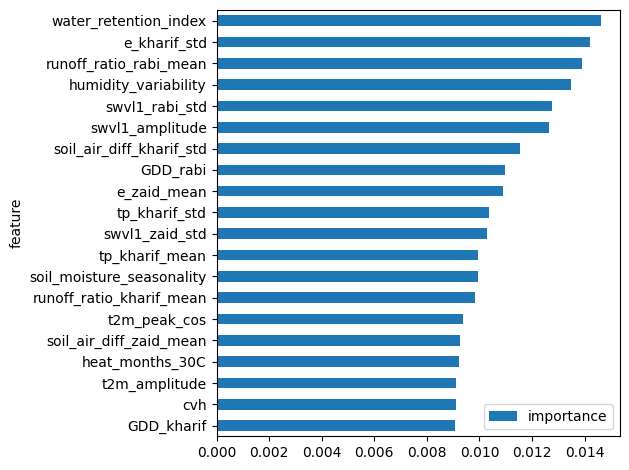

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
importance_df.head(20).plot(x="feature", y="importance", kind="barh")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()